# Credit Card Fraud Detection in the Italian Banking Context

## A CRISP-DM Approach

**Author:** Vincenzo Ambrosino

## 1. Business Understanding

The client is a hypothetical Italian bank.
The bank has a problem: multiple fraudulent transactions caused by phishing, skimming, credential theft, data breaches.
The system should achieve a minimum recall of 85% when detecting fraudulent transactions by estimating their risk level:

| Risk level | Action |
|---|---|
| Low | Payment proceeds |
| Medium | Require 2FA authentication through home banking app |
| High | Suspend the transaction pending further verification |

### Business Constraints

One on the problems that may occur is a Type 1 error also know as a false positive: it is an error where a model wrongly predicts a positive result while the real data is actually negative.
Too many false positives would harm:
-Customers: account freezing, wasted time, loss of trust, churn.
-Bank: operational overload, alert fatigue, reputational damage, lost revenue.

To avoid a large number of false positives the system should be able to confront different elements: transaction destination, customer's usual behaviour, multiple risk factors. 


### Data Question
Can the available transaction data be used to identify fraudulent transactions and distinguish them from legitimate ones while minimizing the number of false positives?

### Analytical Approach

This project will use supervised binary classification because the historical transactions are already labelled.

The model will learn patterns and estimate the probability of fraud for each new transaction.

## 2. Data Understanding



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
print (df.shape)

(284807, 31)


In [4]:
print (df.columns)

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='str')


### Dataset Structure
- 284,807 rows: transactions;
- 31 columns: variables.
- Time: seconds occurred from the first transaction registered in the dataset.
- Amount: transaction's amount.
- Class: variable to predict: 0 -> legitimate transaction, 1 -> fraudulent transaction.
- V1-V28: Anonymized data.

In [5]:
df.info ()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
print (492/ (284315+492) *100, "%")

0.1727485630620034 %


### Class Imbalance

We have a total of 284,315 legitimate transactions and 492 fraudulent ones, with a fraud percentage of 0.173%.
A model that predicted every transaction as legitimate would still achieve approximately 99.83% accuracy while failing to detect any fraud. Therefore, recall and precision are more informative evaluation metrics for this problem.


In [8]:
class_counts = df["Class"].value_counts()
class_counts

Class
0    284315
1       492
Name: count, dtype: int64

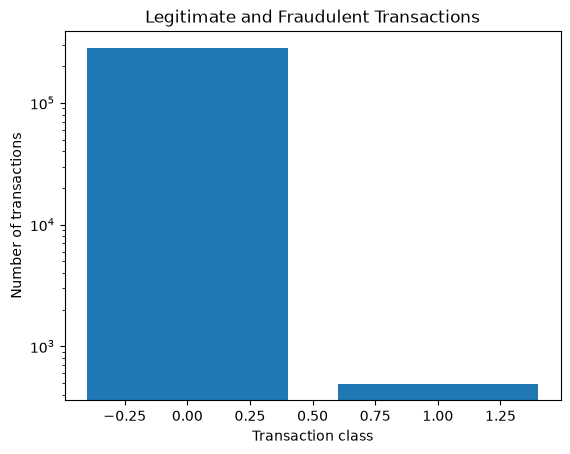

In [9]:
plt.bar(class_counts.index,  class_counts.values)
plt.xlabel("Transaction class")
plt.ylabel("Number of transactions")
plt.title("Legitimate and Fraudulent Transactions")
plt.yscale("log")
plt.show()

In this graph, we can see the disparity between legitimate and fraudulent transactions.

## 3. Data Preparation


In [10]:
df.duplicated().sum()

np.int64(1081)

In [11]:
df_clean = df.drop_duplicates().copy()

In [12]:
df_clean.shape

(283726, 31)

In [13]:
class_counts = df_clean ["Class"].value_counts()
class_counts

Class
0    283253
1       473
Name: count, dtype: int64

In [14]:
removed_by_class = (
    df["Class"].value_counts()
    - df_clean["Class"].value_counts()
)

print(removed_by_class)
print("Total duplicates removed:", removed_by_class.sum())

Class
0    1062
1      19
Name: count, dtype: int64
Total duplicates removed: 1081


In [15]:
df_clean.isnull().sum() .sum

<bound method Series.sum of Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64>

1081 duplicates removed, no value missing.

Cleaned dataset: 283.726 rows and 31 columns.

In [16]:
X = df_clean.drop("Class", axis=1)
y = df_clean["Class"]
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 30)
y shape: (283726,)


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [18]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(226980, 30)
(56746, 30)
(226980,)
(56746,)


In [19]:
print("Training distribution (%):")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution (%):")
print(y_test.value_counts(normalize=True) * 100)

Training distribution (%):
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Test distribution (%):
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


## 4. Modeling

In [20]:
from sklearn.dummy import DummyClassifier

baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)
baseline_predictions = baseline_model.predict(X_test)

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Accuracy:", accuracy_score(y_test, baseline_predictions))
print("Precision:", precision_score(y_test, baseline_predictions, zero_division=0))
print("Recall:", recall_score(y_test, baseline_predictions))
print("F1-score:", f1_score(y_test, baseline_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_test, baseline_predictions))

Accuracy: 0.9983258731892997
Precision: 0.0
Recall: 0.0
F1-score: 0.0
Confusion matrix:
[[56651     0]
 [   95     0]]


The baseline achieved 99.83% accuracy but failed to detect any of the 95 fraudulent transactions. This confirms that accuracy alone is misleading for such an imbalanced dataset and that recall is more important.


### Logistic Regression

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

model_steps = [
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
]

In [23]:
logistic_model = Pipeline(model_steps)
logistic_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [27]:
logistic_predictions = logistic_model.predict(X_test)

In [28]:
print("Accuracy:", accuracy_score(y_test, logistic_predictions))
print("Precision:", precision_score(y_test, logistic_predictions))
print("Recall:", recall_score(y_test, logistic_predictions))
print("F1-score:", f1_score(y_test, logistic_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_test, logistic_predictions))

Accuracy: 0.9753110351390406
Precision: 0.05638586956521739
Recall: 0.8736842105263158
F1-score: 0.10593490746649649
Confusion matrix:
[[55262  1389]
 [   12    83]]


In [29]:
logistic_cm = confusion_matrix(y_test, logistic_predictions)

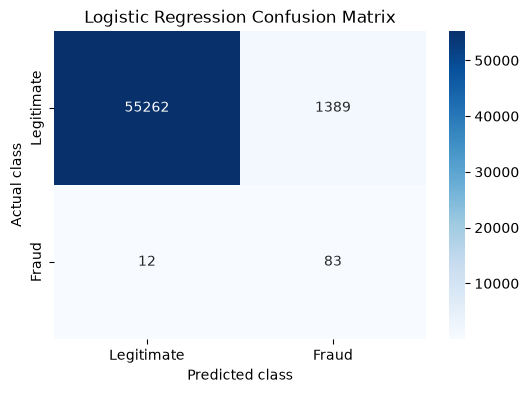

In [30]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [31]:
X_model_train, X_validation, y_model_train, y_validation = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

In [32]:
print(X_model_train.shape)
print(X_validation.shape)

(181584, 30)
(45396, 30)


In [33]:
logistic_model.fit(X_model_train, y_model_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](30,)","['Time','V1','V2',...,'V27','V28','Amount']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,30
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [34]:
validation_probabilities = logistic_model.predict_proba(X_validation)[:, 1]

In [35]:
print(validation_probabilities[:10])

[0.00318895 0.01515062 0.01138963 0.01089404 0.00532812 0.00363928
 0.00350218 0.01782478 0.00113194 0.14385666]


In [36]:
for threshold in [0.50, 0.60, 0.70, 0.80, 0.90]:
    validation_predictions = (validation_probabilities >= threshold).astype(int)

    precision = precision_score(y_validation, validation_predictions)
    recall = recall_score(y_validation, validation_predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.50 | Precision: 0.054 | Recall: 0.895
Threshold: 0.60 | Precision: 0.077 | Recall: 0.895
Threshold: 0.70 | Precision: 0.104 | Recall: 0.895
Threshold: 0.80 | Precision: 0.142 | Recall: 0.868
Threshold: 0.90 | Precision: 0.239 | Recall: 0.868


In [38]:
for threshold in [0.90, 0.92, 0.94, 0.96, 0.98]:
    validation_predictions = (validation_probabilities >= threshold).astype(int)

    precision = precision_score(y_validation, validation_predictions)
    recall = recall_score(y_validation, validation_predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.90 | Precision: 0.239 | Recall: 0.868
Threshold: 0.92 | Precision: 0.283 | Recall: 0.868
Threshold: 0.94 | Precision: 0.330 | Recall: 0.868
Threshold: 0.96 | Precision: 0.410 | Recall: 0.868
Threshold: 0.98 | Precision: 0.537 | Recall: 0.868


In [39]:
for threshold in [0.980, 0.985, 0.990, 0.995, 0.999]:
    validation_predictions = (validation_probabilities >= threshold).astype(int)

    precision = precision_score(y_validation, validation_predictions)
    recall = recall_score(y_validation, validation_predictions)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f}"
    )

Threshold: 0.98 | Precision: 0.537 | Recall: 0.868
Threshold: 0.98 | Precision: 0.555 | Recall: 0.868
Threshold: 0.99 | Precision: 0.575 | Recall: 0.855
Threshold: 0.99 | Precision: 0.613 | Recall: 0.855
Threshold: 1.00 | Precision: 0.756 | Recall: 0.855


In [43]:
selected_threshold = 0.999

logistic_model.fit(X_train, y_train)

test_probabilities = logistic_model.predict_proba(X_test)[:, 1]
tuned_predictions = (test_probabilities >= selected_threshold).astype(int)

print("Accuracy:", accuracy_score(y_test, tuned_predictions))
print("Precision:", precision_score(y_test, tuned_predictions))
print("Recall:", recall_score(y_test, tuned_predictions))
print("F1-score:", f1_score(y_test, tuned_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_test, tuned_predictions))

Accuracy: 0.9991717477883904
Precision: 0.7448979591836735
Recall: 0.7684210526315789
F1-score: 0.7564766839378239
Confusion matrix:
[[56626    25]
 [   22    73]]


In [44]:
selected_threshold = 0.70

tuned_predictions = (
    test_probabilities >= selected_threshold
).astype(int)

In [45]:
print("Accuracy:", accuracy_score(y_test, tuned_predictions))
print("Precision:", precision_score(y_test, tuned_predictions))
print("Recall:", recall_score(y_test, tuned_predictions))
print("F1-score:", f1_score(y_test, tuned_predictions))
print("Confusion matrix:")
print(confusion_matrix(y_test, tuned_predictions))

Accuracy: 0.9886159376872379
Precision: 0.11576011157601115
Recall: 0.8736842105263158
F1-score: 0.2044334975369458
Confusion matrix:
[[56017   634]
 [   12    83]]


### Tuned Model Evaluation

Using a threshold of 0.70, the model detected 83 out of 95 fraudulent transactions, achieving a recall of 87.37% and meeting the business target.

Compared with the default threshold, false positives decreased from 1,389 to 634 without reducing the number of detected frauds. Precision also improved from 5.64% to 11.58%.

Although false positives remain, the tuned model provides a better balance between fraud detection and unnecessary transaction reviews.

In [46]:
tuned_cm = confusion_matrix(y_test, tuned_predictions)

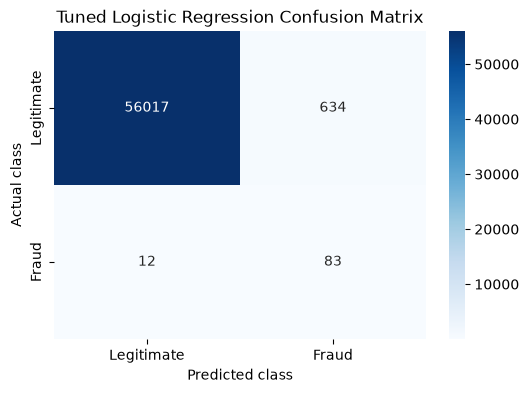

In [47]:
tuned_cm = confusion_matrix(y_test, tuned_predictions)

plt.figure(figsize=(6, 4))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Legitimate", "Fraud"],
    yticklabels=["Legitimate", "Fraud"]
)

plt.xlabel("Predicted class")
plt.ylabel("Actual class")
plt.title("Tuned Logistic Regression Confusion Matrix")
plt.show("Tuned Logistic Regression Confusion Matrix")

### Model Comparison

| Model | Accuracy | Precision | Recall | F1-score | False Positives | Missed Frauds |
|---|---:|---:|---:|---:|---:|---:|
| Baseline | 99.83% | 0.00% | 0.00% | 0.00% | 0 | 95 |
| Logistic Regression (0.50) | 97.53% | 5.64% | 87.37% | 10.59% | 1,389 | 12 |
| Tuned Logistic Regression (0.70) | 98.86% | 11.58% | 87.37% | 20.44% | 634 | 12 |

## 6. Deployment and Business Recommendations

The model could assign a fraud risk score to each new transaction in real time.

| Fraud risk score | Risk level | Recommended action |
|---|---|---|
| Below 0.50 | Low | Allow the transaction |
| From 0.50 to below 0.70 | Medium | Require confirmation through 2FA |
| 0.70 or higher | High | Temporarily suspend the transaction for additional verification |

The selected threshold of 0.70 allows the system to detect 87.37% of fraudulent transactions while reducing false positives compared with the default model.

The bank should continuously monitor precision, recall and customer feedback. The model should also be retrained periodically using newer confirmed transactions.

## 7. Limitations

* The dataset contains European transactions from September 2013 and is not specifically related to Italian banks.
* The variables V1–V28 are anonymized, making their individual meaning difficult to interpret.
* The dataset identifies fraudulent transactions but does not specify whether they were caused by phishing, skimming or other methods.
* This project is an educational prototype based on historical data and is not ready for use in a real banking system.
* A real implementation would require recent local data, continuous monitoring, model retraining and additional security and privacy evaluations.


## 8. Conclusion

The baseline model achieved very high accuracy but failed to detect any fraudulent transaction, demonstrating that accuracy alone is misleading for an imbalanced dataset.

The final Logistic Regression model, using a threshold of 0.70, detected 83 out of 95 fraudulent transactions and achieved a recall of 87.37%, meeting the initial business target. It also reduced false positives from 1,389 to 634 without detecting fewer frauds.

These results show that adjusting the classification threshold can create a better balance between fraud detection and unnecessary customer verification.
